# 05. Model Readiness & Advanced Insights
Đây là bước cuối cùng trong quy trình EDA. Chúng ta sẽ chuẩn bị dữ liệu sạch nhất để đưa vào huấn luyện mô hình, đồng thời khám phá các cụm từ (N-grams) và chủ đề (Topics) đặc trưng của Spam.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_selection import mutual_info_classif

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

plt.style.use('seaborn-v0_8-darkgrid')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\minhp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## 1. Load Dữ liệu
Sử dụng output từ Notebook 04.

In [3]:
df = pd.read_csv('../data/processed/04_final_features.csv')
print(f"Loaded dataset with {df.shape[0]} rows and {df.shape[1]} columns.")

## Ensure temporal features exist
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df['month'] = df['Date'].dt.month
    df['hour'] = df['Date'].dt.hour
    df['is_weekend'] = df['Date'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0)
    print("Temporal features 'month', 'hour', 'is_weekend' recreated.")


Loaded dataset with 33664 rows and 16 columns.
Temporal features 'month', 'hour', 'is_weekend' recreated.


## 2. NLP Pipeline: Trích xuất Cleaned Message
Làm sạch văn bản triệt để để model training hiệu quả hơn.

In [4]:
def clean_message(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    # Xóa dấu câu
    text = ''.join([c for c in text if c not in string.punctuation])
    # Xóa stopwords và tokenization đơn giản
    words = [w for w in text.split() if w not in stop_words and len(w) > 2]
    return " ".join(words)

print("Cleaning messages... (this may take a moment)")
df['cleaned_message'] = df['Message'].apply(clean_message)
print("Feature 'cleaned_message' created.")

Cleaning messages... (this may take a moment)
Feature 'cleaned_message' created.


## 3. Phân tích N-grams (Cụm từ)
Khám phá các cụm 2 từ (Bigrams) và 3 từ (Trigrams) phổ biến nhất trong Spam.

C:\Users\minhp\AppData\Local\Temp\ipykernel_19428\2270992777.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=temp_df, x='count', y='ngram', palette='viridis')


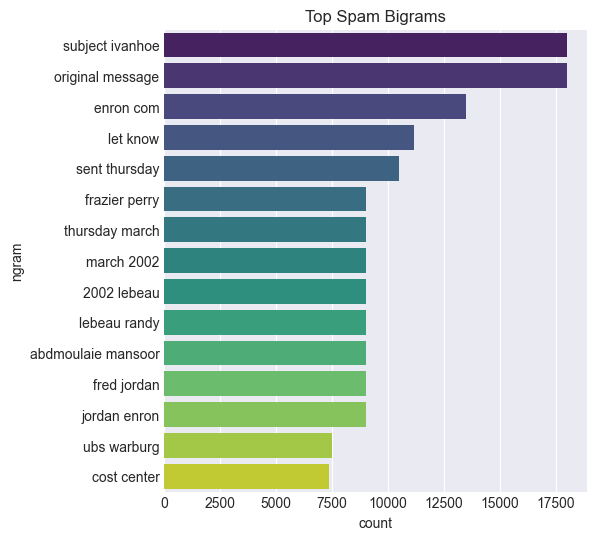

C:\Users\minhp\AppData\Local\Temp\ipykernel_19428\2270992777.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=temp_df, x='count', y='ngram', palette='viridis')


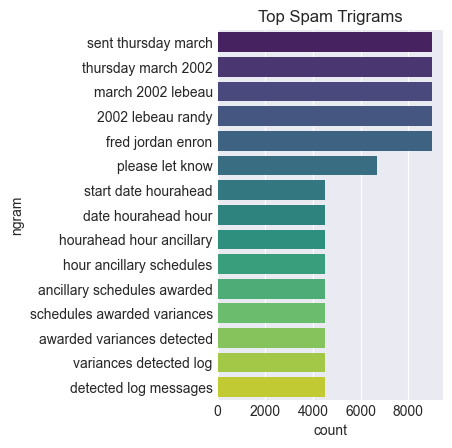

In [5]:
def plot_top_ngrams(text_series, n=2, top_k=15, title="Top N-grams"):
    vectorizer = CountVectorizer(ngram_range=(n, n)).fit(text_series)
    bag_of_words = vectorizer.transform(text_series)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:top_k]
    
    temp_df = pd.DataFrame(words_freq, columns=['ngram', 'count'])
    sns.barplot(data=temp_df, x='count', y='ngram', palette='viridis')
    plt.title(title)
    plt.show()

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plot_top_ngrams(df[df['label']==1]['cleaned_message'], n=2, title="Top Spam Bigrams")
plt.subplot(1, 2, 2)
plot_top_ngrams(df[df['label']==1]['cleaned_message'], n=3, title="Top Spam Trigrams")

## 4. Topic Modeling (LDA)
Phân nhóm email thành các chủ đề ẩn.

In [6]:
vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
tfidf_matrix = vectorizer.fit_transform(df['cleaned_message'])

lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(tfidf_matrix)

words = vectorizer.get_feature_names_out()
for idx, topic in enumerate(lda.components_):
    print(f"Topic {idx+1}: {', '.join([words[i] for i in topic.argsort()[:-11:-1]])}")

Topic 1: tenaska, hsbc, ena, iris, antonella, january, gas, enron, hill, garrick
Topic 2: ect, enron, vince, 2000, hou, com, 2001, thanks, deal, subject
Topic 3: cost, ubs, transfers, center, management, 2001, point, time, friday, consolidated
Topic 4: final, type, schedule, schedules, trans, date, hourahead, hour, iso, variances
Topic 5: ivanhoe, fred, 2002, jordan, subject, perry, randy, mansoor, frazier, abdmoulaie


## 5. Feature Importance Baseline
Sử dụng Mutual Information để xem đặc trưng nào 'ăn tiền' nhất.

C:\Users\minhp\AppData\Local\Temp\ipykernel_19428\1585732329.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mi_df, x='mi_score', y='feature', palette='magma')


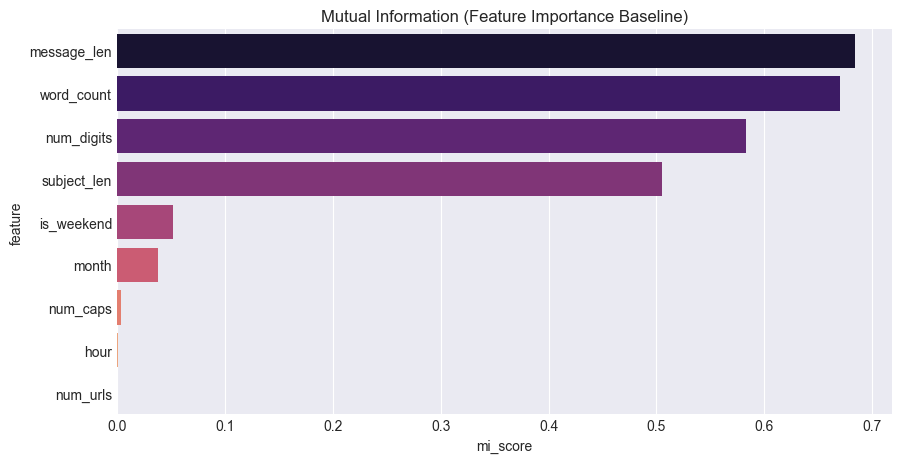

In [7]:
numeric_features = ['message_len', 'subject_len', 'word_count', 'num_caps', 'num_digits', 'num_urls', 'month', 'hour', 'is_weekend']
X = df[numeric_features].fillna(0)
y = df['label']

mi_scores = mutual_info_classif(X, y)
mi_df = pd.DataFrame({'feature': numeric_features, 'mi_score': mi_scores}).sort_values('mi_score', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=mi_df, x='mi_score', y='feature', palette='magma')
plt.title('Mutual Information (Feature Importance Baseline)')
plt.show()

## 6. Export Modeling Dataset
Lưu file cuối cùng để chuyển sang giai đoạn Training.

In [8]:
df.to_csv('../data/processed/05_model_ready.csv', index=False)
print("Final EDA process complete! Saved to 05_model_ready.csv")
print("You are now ready to train your Spam Classifier!")

Final EDA process complete! Saved to 05_model_ready.csv
You are now ready to train your Spam Classifier!
